# Evaluación 1 — Calidad y Preparación de Datos
### E1 – EDA · Rendimiento académico

**Integrantes:**
- Alexis Arévalo - alexis.arevalo2301@alumnos.ubiobio.cl
- Gabriel Ascencio — gabriel.ascencio2301@alumnos.ubiobio.cl
- Alonso Barra — alonso.barra2301@alumnos.ubiobio.cl
- Cristobal Bravo — cristobal.bravo2201@alumnos.ubiobio.cl

**Descripción:** proceso reproducible de diagnóstico de calidad, análisis exploratorio (EDA), tratamiento de datos e implementación de un `Pipeline`/`ColumnTransformer` sobre el archivo `rendimiento_academico_evaluacion.csv`. El resultado es un dataset tratado exportado como `rendimiento_academico_limpio.csv`.

> Cada decisión de tratamiento está **justificada** en los hallazgos del diagnóstico (no se aplican transformaciones mecánicas).


## Contexto del problema

Una institución de educación superior desea analizar el rendimiento académico
de sus estudiantes mediante un conjunto de datos que contiene información
demográfica, hábitos de estudio, antecedentes académicos y rendimiento final.

Antes de utilizar estos datos en procesos de análisis o modelos predictivos,
es necesario evaluar su calidad, identificar posibles problemas y aplicar
estrategias adecuadas de preparación.

El presente trabajo desarrolla un proceso completo de diagnóstico,
análisis exploratorio y tratamiento de datos, generando finalmente un dataset
limpio y preparado para futuros modelos de aprendizaje automático.



## Objetivo

El objetivo de esta evaluación es desarrollar un proceso reproducible que permita:

- Diagnosticar la calidad del dataset.
- Identificar problemas presentes en los datos.
- Realizar análisis exploratorio.
- Responder preguntas de investigación.
- Definir estrategias de tratamiento.
- Implementar transformaciones mediante Pipeline y ColumnTransformer.
- Generar un dataset final tratado.

## 0. Carga del set de datos

In [30]:
!wget -O rendimiento_academico_evaluacion.csv "https://raw.githubusercontent.com/ale-are/IA-Ev1/refs/heads/main/E1%20-%20EDA/rendimiento_academico_evaluacion.csv"

--2026-09-04 05:48:32--  https://raw.githubusercontent.com/ale-are/IA-Ev1/refs/heads/main/E1%20-%20EDA/rendimiento_academico_evaluacion.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 382638 (374K) [text/plain]
Saving to: ‘rendimiento_academico_evaluacion.csv’

rendimiento_academi 100%[===================>] 373.67K  --.-KB/s    in 0.006s  

2026-09-04 05:48:32 (61.6 MB/s) - ‘rendimiento_academico_evaluacion.csv’ saved [382638/382638]



In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

df = pd.read_csv("rendimiento_academico_evaluacion.csv")
df_original = df.copy()   # copia intacta para la comparación final
print("Dataset cargado:", df.shape)
df.head()


Dataset cargado: (5100, 11)


,StudentID,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship,Program,FinalGrade
0,STU-10522,22.0,10.70,83.73,6.09,69.15,6.27,4.39,Sí,Ingeniería Industrial,3.96
1,STU-10947,65.0,9.86,99.60,6.76,76.95,6.52,8.03,No,Ingeniería Informática,5.09
2,STU-11352,26.0,13.43,92.65,6.07,95.99,6.70,6.37,No,Contador Auditor,4.37
3,STU-12298,27.0,20.77,81.73,5.09,90.96,6.16,5.81,No,Contador Auditor,4.02
4,STU-13527,20.0,6.27,70.17,4.84,64.20,6.30,4.10,No,Ingeniería Civil,3.24


---
# 1. Diagnóstico de calidad de datos

Diccionario de dominios válidos según el `Metadata.md` y el sentido de cada variable:

| Variable | Dominio válido |
|---|---|
| Age | 16 – 60 años |
| StudyHours | 0 – 80 h/semana |
| Attendance | 0 – 100 % |
| PreviousGPA | 1 – 10 |
| AssignmentsCompleted | 0 – 100 % |
| SleepHours | 0 – 24 h/día |
| InternetHours | 0 – 24 h/día |
| FinalGrade | 1 – 10 (target) |


In [32]:
# Dominios válidos (se usarán en diagnóstico y tratamiento)
DOMINIOS = {
    "Age": (16, 60),
    "StudyHours": (0, 80),
    "Attendance": (0, 100),
    "PreviousGPA": (1, 10),
    "AssignmentsCompleted": (0, 100),
    "SleepHours": (0, 24),
    "InternetHours": (0, 24),
    "FinalGrade": (1, 10),
}
ID_COL   = "StudentID"
TARGET   = "FinalGrade"
NUMERICAS   = ["Age","StudyHours","Attendance","PreviousGPA","AssignmentsCompleted","SleepHours","InternetHours"]
CATEGORICAS = ["Scholarship","Program"]


### 1.1 Caracterización del dataset

In [33]:
print("Cantidad de registros :", df.shape[0])
print("Cantidad de variables :", df.shape[1])
print("\nTipos de datos:")
print(df.dtypes)

resumen = pd.DataFrame({
    "tipo_dato": df.dtypes.astype(str),
    "rol": ["Identificador" if c==ID_COL else ("Target" if c==TARGET else "Feature") for c in df.columns],
    "naturaleza": ["Categórica" if c in CATEGORICAS+[ID_COL] else "Numérica" for c in df.columns],
})
resumen


Cantidad de registros : 5100
Cantidad de variables : 11

Tipos de datos:
StudentID                object
Age                     float64
StudyHours              float64
Attendance              float64
PreviousGPA             float64
AssignmentsCompleted    float64
SleepHours              float64
InternetHours           float64
Scholarship              object
Program                  object
FinalGrade              float64
dtype: object


,tipo_dato,rol,naturaleza
StudentID,object,Identificador,Categórica
Age,float64,Feature,Numérica
StudyHours,float64,Feature,Numérica
Attendance,float64,Feature,Numérica
PreviousGPA,float64,Feature,Numérica
AssignmentsCompleted,float64,Feature,Numérica
SleepHours,float64,Feature,Numérica
InternetHours,float64,Feature,Numérica
Scholarship,object,Feature,Categórica
Program,object,Feature,Categórica


El conjunto de datos contiene 5.100 registros y 11 variables, de las cuales 8 son numericas `float64`: `Age` , `StudyHours`, `Attendance`, `PreviousGPA`,
`AssignmentsCompleted`, `SleepHours`, `InternetHours` y `FinalGrade`. Las 3 restantes son categoricas `object`: `StudentID`, `Scholarship` y `Program`.

La variable `StudentID` corresponde al **identificador de cada estudiante** y `FinalGrade` el **resultado academico**

### 1.2 Valores faltantes
Los valores faltantes respresentan informacion ausente dentro del conjunto de datos, afectando el analisis y el desempeño de modelos de aprendizaje.
En esta seccion se identifica la cantidad y proporcion de valores faltantes por variable con el objetivo de definir estrategias de tratamiento adecuado.

In [34]:
falt = pd.DataFrame({
    "Cantidad": df.isna().sum(),
    "Porcentaje": (df.isna().mean()*100).round(2)
}).sort_values("Cantidad", ascending=False)
falt


,Cantidad,Porcentaje
Attendance,224,4.39
AssignmentsCompleted,216,4.24
StudyHours,181,3.55
InternetHours,176,3.45
PreviousGPA,162,3.18
SleepHours,122,2.39
Age,103,2.02
Scholarship,81,1.59
Program,70,1.37
StudentID,0,0.00


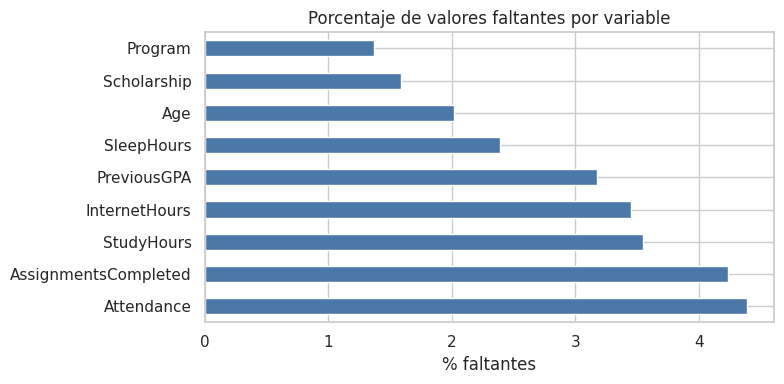

In [35]:
ax = falt[falt.Cantidad>0]["Porcentaje"].plot(kind="barh", color="#4C78A8")
ax.set_xlabel("% faltantes"); ax.set_title("Porcentaje de valores faltantes por variable")
plt.tight_layout(); plt.show()


El análisis de valores faltantes evidencia que existen datos ausentes en
diversas variables del conjunto de datos. La mayor cantidad de valores faltantes
se encuentra en la variable `Attendance`, con 224 registros ausentes,
equivalentes al 4.39% del total de observaciones.

Le siguen `AssignmentsCompleted` con 216 registros (4.24%) y `StudyHours` con
181 registros (3.55%).

No se identifican valores faltantes en las variables `StudentID` y `FinalGrade`,
por lo que el identificador de los estudiantes y la variable objetivo mantienen
su integridad.

**Estrategia (se justifica y aplica en la sección 3/4):** Los porcentajes son bajos (<5 %), por lo que **eliminar filas descartaría demasiada información**. Se opta por **imputación**: mediana para numéricas (robusta ante outliers) y moda para categóricas.

### 1.3 Registros duplicados

In [36]:
dup_full = df.duplicated().sum()
dup_id   = df[ID_COL].duplicated().sum()
print("Filas totalmente duplicadas :", dup_full, f"({dup_full/len(df)*100:.2f}%)")
print("StudentID duplicados        :", dup_id,   f"({dup_id/len(df)*100:.2f}%)")
print("StudentID únicos            :", df[ID_COL].nunique(), "de", len(df))


Filas totalmente duplicadas : 100 (1.96%)
StudentID duplicados        : 100 (1.96%)
StudentID únicos            : 5000 de 5100


Se identificaron 100 registros duplicados completos, correspondientes al **1.96%** del dataset (5100 registros totales). Además, se encontraron 100 valores repetidos en la variable StudentID, quedando 5000 identificadores únicos.

Para identificar los duplicados se utilizaron:

*   Duplicación de filas completas (df.duplicated()).
*   Repetición del identificador StudentID.

Debido a que los registros duplicados contienen la misma información y no aportan nuevos datos al análisis, se eliminarán durante la etapa de limpieza para evitar sesgos en los resultados posteriores.

### 1.4 Inconsistencias (valores fuera de dominio)

In [37]:
# Inconsistencias en categóricas: mismo valor escrito de distinta forma
for c in CATEGORICAS:
    print(f"--- {c} ---")
    print(df[c].value_counts(dropna=False))
    print()


--- Scholarship ---
Scholarship
No     3364
Sí     1620
NaN      81
si       10
No       10
NO        8
SÍ        5
SI        2
Name: count, dtype: int64

--- Program ---
Program
Ingeniería Informática     1424
Ingeniería Industrial      1119
Ingeniería Civil           1004
Administración              787
Contador Auditor            660
NaN                          70
Ingenieria Informatica       10
INGENIERÍA INFORMÁTICA        7
Ingeniería Civil              5
INGENIERÍA CIVIL              4
Ingeniería informática        4
ADMINISTRACIÓN                3
Administracion                3
Name: count, dtype: int64



In [38]:
# Inconsistencias en numéricas: valores imposibles según el dominio
print("Valores fuera de dominio (inválidos):")
for c, (lo, hi) in DOMINIOS.items():
    n = ((df[c] < lo) | (df[c] > hi)).sum()
    if n:
        print(f"  {c:22s} fuera de [{lo},{hi}] -> {n} casos "
              f"(min={df[c].min():.2f}, max={df[c].max():.2f})")


Valores fuera de dominio (inválidos):
  Age                    fuera de [16,60] -> 15 casos (min=18.00, max=80.00)
  StudyHours             fuera de [0,80] -> 9 casos (min=1.00, max=98.33)
  Attendance             fuera de [0,100] -> 20 casos (min=-19.96, max=122.97)
  SleepHours             fuera de [0,24] -> 8 casos (min=-7.71, max=11.00)
  InternetHours          fuera de [0,24] -> 31 casos (min=0.50, max=69.50)
  FinalGrade             fuera de [1,10] -> 4 casos (min=-1.46, max=8.01)


**Diagnóstico:**  
Se analizaron inconsistencias en variables categóricas y numéricas considerando las restricciones propias de cada variable.

En las variables categóricas se identificaron diferencias de escritura para una misma categoría:

* Scholarship: presenta variantes como Sí, SI, SÍ, Si, si, además de valores nulos. Estas diferencias deben normalizarse para mantener únicamente las categorías válidas.
* Program: se encontraron variaciones por uso de mayúsculas, minúsculas y acentos (por ejemplo, Ingeniería Informática, INGENIERÍA INFORMÁTICA, Ingenieria Informatica). Estas corresponden a la misma categoría escrita de distintas formas.   

En las variables numéricas se detectaron valores imposibles (inválidos, distinto de un extremo):
- `Attendance`: negativos y valores > 100 %.
- `SleepHours`: horas negativas.
- `FinalGrade`: notas negativas (escala 1–10).
- `InternetHours`: valores > 24 h diarias.
- `Age`: edades fuera de un rango razonable de estudiante.

**Estrategia de tratamiento:** Las variables categóricas serán normalizadas para unificar categorías equivalentes.
Los valores numéricos fuera de dominio serán considerados datos inválidos y transformados a valores faltantes (NaN) para posteriormente ser tratados mediante imputación dentro del Pipeline.

### 1.5 Valores atípicos (outliers)

In [39]:
def resumen_outliers(data, cols):
    filas=[]
    for c in cols:
        s=data[c].dropna()
        q1,q3=s.quantile([.25,.75]); iqr=q3-q1
        lo,hi=q1-1.5*iqr,q3+1.5*iqr
        n=((s<lo)|(s>hi)).sum()
        filas.append([c,round(lo,2),round(hi,2),int(n),round(n/len(s)*100,2)])
    return pd.DataFrame(filas,columns=["variable","lim_inf","lim_sup","n_outliers","pct"])

resumen_outliers(df, NUMERICAS+[TARGET])


,variable,lim_inf,lim_sup,n_outliers,pct
0,Age,13.50,33.50,63,1.26
1,StudyHours,-1.29,25.48,49,1.00
2,Attendance,54.43,116.16,27,0.55
3,PreviousGPA,3.70,7.75,21,0.43
4,AssignmentsCompleted,39.62,136.23,17,0.35
5,SleepHours,3.61,10.41,34,0.68
6,InternetHours,-3.09,15.28,145,2.94
7,FinalGrade,1.48,6.89,37,0.73


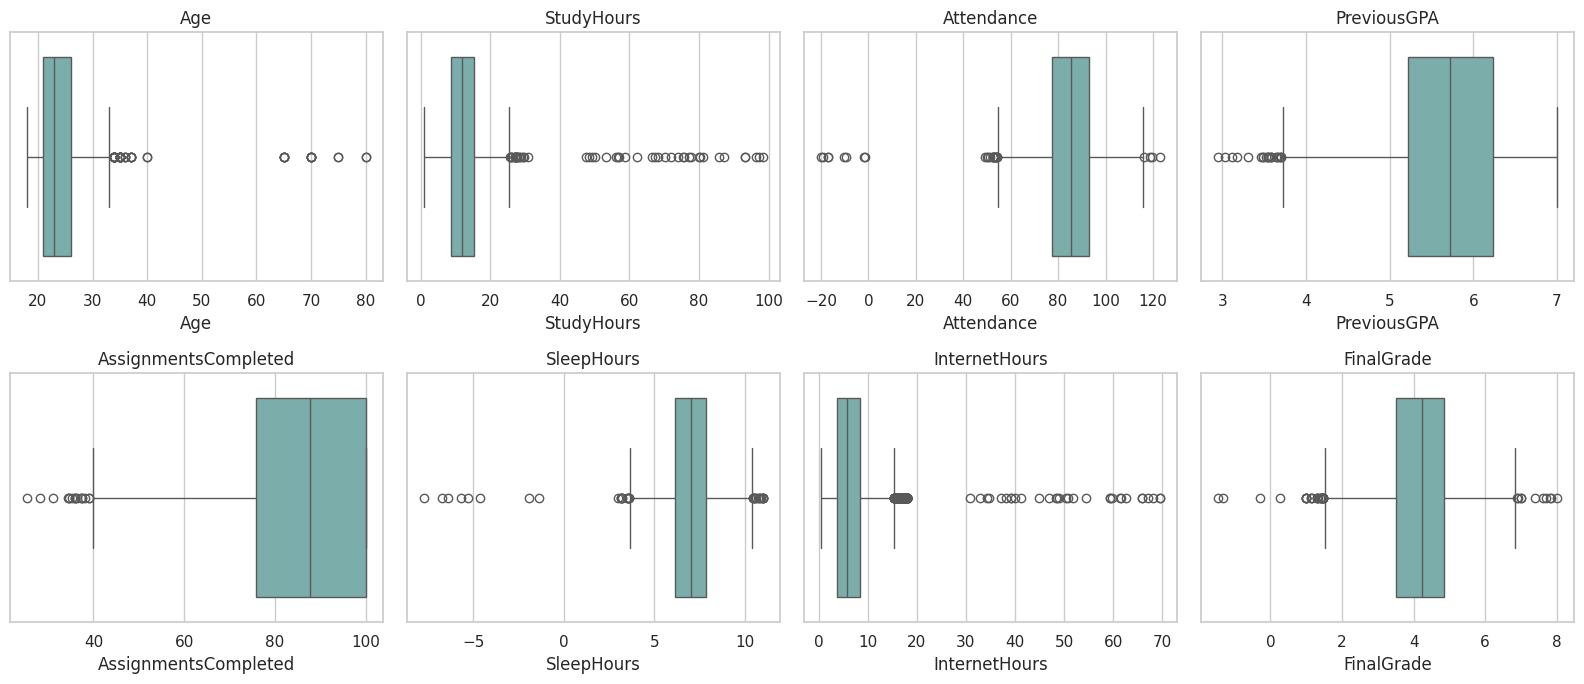

In [40]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, c in zip(axes.ravel(), NUMERICAS+[TARGET]):
    sns.boxplot(x=df[c], ax=ax, color="#72B7B2"); ax.set_title(c)
plt.tight_layout(); plt.show()


**Análisis de valores atípicos**

Para detectar valores atípicos en las variables numéricas se utilizó el método del rango intercuartílico (IQR), considerando como outliers aquellos valores ubicados fuera de los límites:

$$ Límite\ inferior = Q1 - 1.5 \times IQR $$ $$ Límite\ superior = Q3 + 1.5 \times IQR $$

Los resultados muestran que la variable con mayor cantidad de valores atípicos corresponde a **InternetHours**, con 145 registros (2.94%), seguida de **Age**, con 63 registros (1.26%), y **StudyHours**, con 49 registros (1.00%).

| Variable con mayor presencia de outliers | Cantidad | Proporción |
| ---------------------------------------- | -------: | ---------: |
| InternetHours                            |      145 |      2.94% |
| Age                                      |       63 |      1.26% |
| StudyHours                               |       49 |      1.00% |


Es importante diferenciar entre valores atípicos y valores inválidos. Algunos valores detectados mediante IQR pueden representar comportamientos extremos pero posibles (por ejemplo, un estudiante con muchas horas de estudio o uso elevado de internet). En cambio, valores que no cumplen restricciones de dominio, como horas negativas o edades imposibles, fueron tratados previamente como inconsistencias.

**Estrategia de tratamiento**  
Los valores identificados como outliers válidos serán conservados para evitar pérdida de información. Los valores imposibles serán transformados a valores faltantes y tratados mediante imputación dentro del Pipeline.

---
# 2. Análisis exploratorio de datos (EDA)

Para el EDA se trabaja sobre una copia con las **inconsistencias corregidas** (texto normalizado y valores inválidos → `NaN`), de modo que las estadísticas y gráficos no queden distorsionados por datos imposibles.

In [41]:
import unicodedata

def normaliza_scholarship(x):
    if pd.isna(x): return np.nan
    s=str(x).strip().lower()
    if s.startswith("s"): return "Sí"
    if s.startswith("n"): return "No"
    return np.nan

def normaliza_program(x):
    if pd.isna(x): return np.nan
    s=str(x).strip()
    s="".join(c for c in unicodedata.normalize("NFKD",s) if not unicodedata.combining(c))
    s=s.upper()
    mapa={
        "INGENIERIA INFORMATICA":"Ingeniería Informática",
        "INGENIERIA INDUSTRIAL":"Ingeniería Industrial",
        "INGENIERIA CIVIL":"Ingeniería Civil",
        "ADMINISTRACION":"Administración",
        "CONTADOR AUDITOR":"Contador Auditor",
    }
    return mapa.get(s, np.nan)

df_eda = df.copy()
df_eda["Scholarship"]=df_eda["Scholarship"].map(normaliza_scholarship)
df_eda["Program"]=df_eda["Program"].map(normaliza_program)
for c,(lo,hi) in DOMINIOS.items():
    df_eda.loc[(df_eda[c]<lo)|(df_eda[c]>hi), c]=np.nan

print("Scholarship:", df_eda['Scholarship'].value_counts(dropna=False).to_dict())
print("Program:", df_eda['Program'].value_counts(dropna=False).to_dict())


Scholarship: {'No': 3382, 'Sí': 1637, nan: 81}
Program: {'Ingeniería Informática': 1445, 'Ingeniería Industrial': 1119, 'Ingeniería Civil': 1013, 'Administración': 793, 'Contador Auditor': 660, nan: 70}


### 2.1 Distribución de las variables numéricas

In [42]:
df_eda[NUMERICAS].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
Age,4982.0,23.66,3.88,18.00,21.00,23.00,26.00,40.00
StudyHours,4910.0,12.28,6.02,1.00,8.74,12.00,15.42,79.92
Attendance,4856.0,84.76,10.40,49.01,77.59,85.46,92.95,100.00
PreviousGPA,4938.0,5.71,0.73,2.95,5.22,5.72,6.23,7.00
AssignmentsCompleted,4884.0,85.21,14.24,25.34,75.85,87.76,100.00,100.00
SleepHours,4970.0,7.01,1.24,3.00,6.16,7.03,7.86,11.00
InternetHours,4893.0,6.39,3.50,0.50,3.79,5.79,8.34,18.00


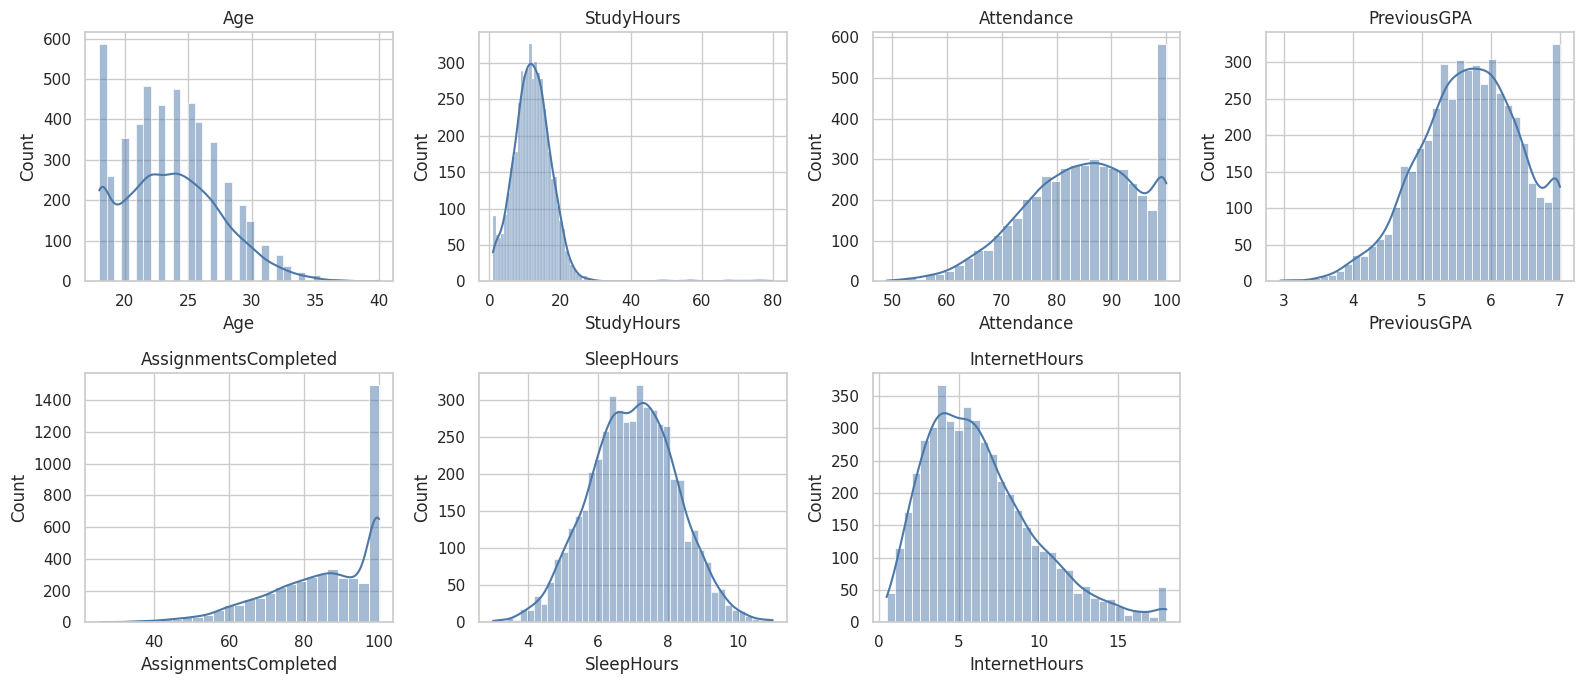

In [43]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, c in zip(axes.ravel(), NUMERICAS):
    sns.histplot(df_eda[c].dropna(), kde=True, ax=ax, color="#4C78A8"); ax.set_title(c)
axes.ravel()[-1].axis("off")
plt.tight_layout(); plt.show()


**Interpretación:**
Las variables académicas presentan distribuciones coherentes después del tratamiento de inconsistencias. `Attendance` presenta valores concentrados en niveles altos, con una media de 84.76%, mientras que `StudyHours` presenta una media de 12.28 horas. `PreviousGPA` y `AssignmentsCompleted` muestran una concentración hacia valores elevados, indicando estudiantes con antecedentes académicos y cumplimiento de actividades relativamente altos. `Age` presenta una distribución sesgada hacia edades menores, concentrándose principalmente entre 20 y 26 años.

### 2.2 Comportamiento de las variables categóricas

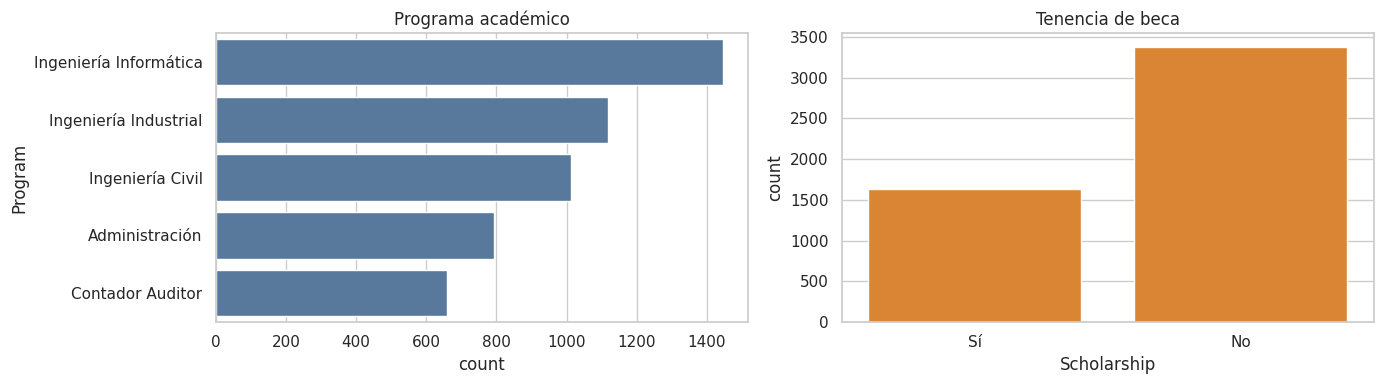

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(y="Program", data=df_eda, order=df_eda["Program"].value_counts().index, ax=axes[0], color="#4C78A8")
axes[0].set_title("Programa académico")
sns.countplot(x="Scholarship", data=df_eda, ax=axes[1], color="#F58518")
axes[1].set_title("Tenencia de beca")
plt.tight_layout(); plt.show()


**Interpretación:** La distribución por programa muestra una mayor representación de Ingeniería Informática (1445 estudiantes), mientras que Contador Auditor presenta la menor cantidad de registros (660). En cuanto a becas, predomina la categoría "No", con 3382 estudiantes frente a 1637 con beca, indicando que aproximadamente dos tercios de los estudiantes no poseen beneficio.

### 2.3 Distribución de FinalGrade

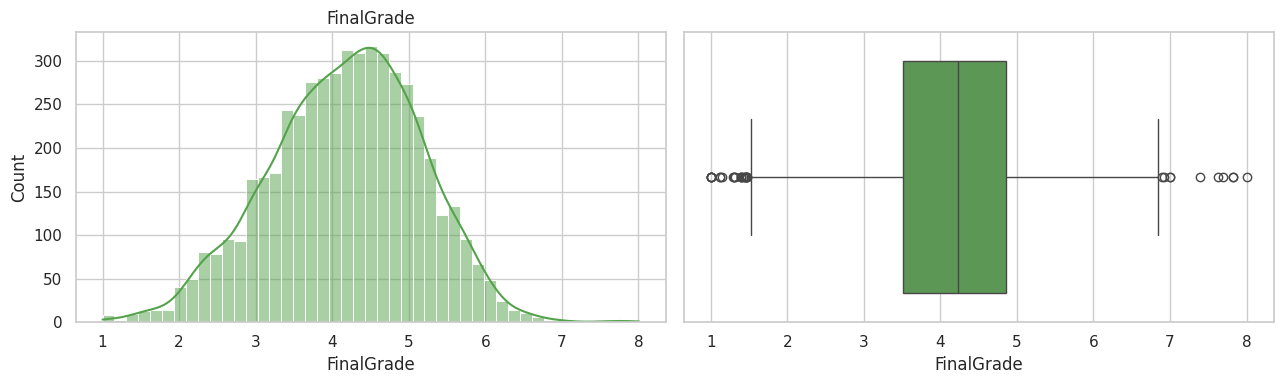

count    5096.00
mean        4.17
std         0.98
min         1.00
25%         3.51
50%         4.23
75%         4.86
max         8.01
Name: FinalGrade, dtype: float64


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df_eda[TARGET], kde=True, ax=axes[0], color="#54A24B"); axes[0].set_title("FinalGrade")
sns.boxplot(x=df_eda[TARGET], ax=axes[1], color="#54A24B")
plt.tight_layout(); plt.show()
print(df_eda[TARGET].describe().round(2))


**Interpretación:** La variable objetivo `FinalGrade` presenta una distribución aproximadamente simétrica alrededor de 4.2 puntos. La mayoría de las observaciones se encuentra entre 3.51 y 4.86 puntos, con algunos valores extremos identificados mediante el análisis de outliers.

### 2.4 Relaciones entre variables

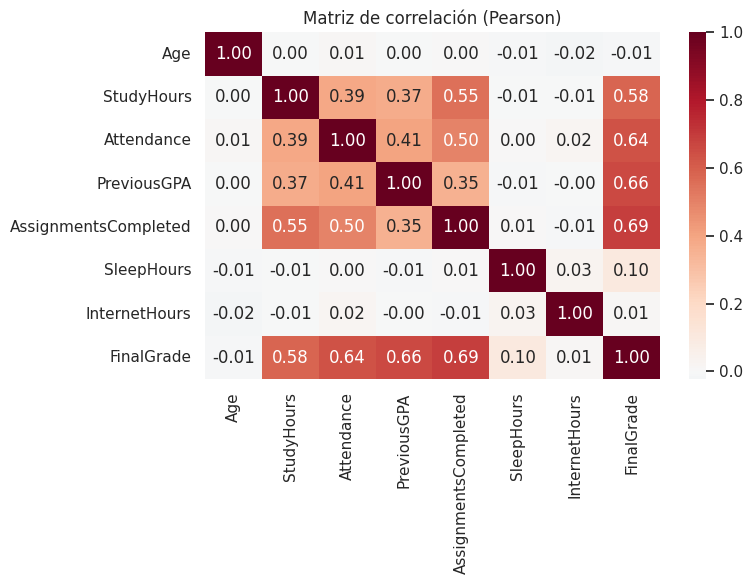

In [46]:
corr = df_eda[NUMERICAS+[TARGET]].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Matriz de correlación (Pearson)"); plt.tight_layout(); plt.show()


**Interpretación:** La matriz de correlación muestra que las variables con mayor relación positiva con `FinalGrade` son `AssignmentsCompleted` (0.69), `PreviousGPA` (0.66), `Attendance` (0.64) y `StudyHours` (0.58). Esto indica que los estudiantes con mayor cumplimiento de actividades, mejor rendimiento previo, mayor asistencia y más horas de estudio tienden a obtener mejores calificaciones finales. Variables como `Age`, `SleepHours` e `InternetHours` presentan correlaciones débiles con el rendimiento académico.

In [47]:
df_eda.groupby("Scholarship")["FinalGrade"].mean()


,FinalGrade
Scholarship,
No,4.077319
Sí,4.371973


**Interpretación:**

Se observa una diferencia en el rendimiento promedio según la tenencia de beca. Los estudiantes con beca presentan una nota final promedio de 4.37, mientras que aquellos sin beca alcanzan un promedio de 4.08.

Esto representa una diferencia aproximada de 0.29 puntos, sugiriendo una posible relación entre la condición de becario y el rendimiento académico. Sin embargo, esta diferencia no implica causalidad, ya que pueden existir otros factores asociados al desempeño estudiantil.

In [48]:
df_eda.groupby("Program")["FinalGrade"].mean()

,FinalGrade
Program,
Administración,4.227343
Contador Auditor,4.050926
Ingeniería Civil,4.111008
Ingeniería Industrial,4.200809
Ingeniería Informática,4.231643


**Interpretación:**  
El rendimiento promedio presenta diferencias pequeñas entre los distintos programas académicos.

Ingeniería Informática presenta el promedio más alto seguida de Administración. Por otro lado, Contador Auditor presenta el promedio menor con 4.05.

Las diferencias observadas son reducidas, por lo que el programa académico por sí solo no parece explicar grandes variaciones en el rendimiento final.

### Preguntas de investigación

**Pregunta 1 — ¿Difiere el promedio de FinalGrade entre estudiantes con y sin beca?**

              mean  count
Scholarship              
No           4.077   3379
Sí           4.372   1636

Diferencia (Sí - No) = 0.295 -> mayor promedio: Con beca


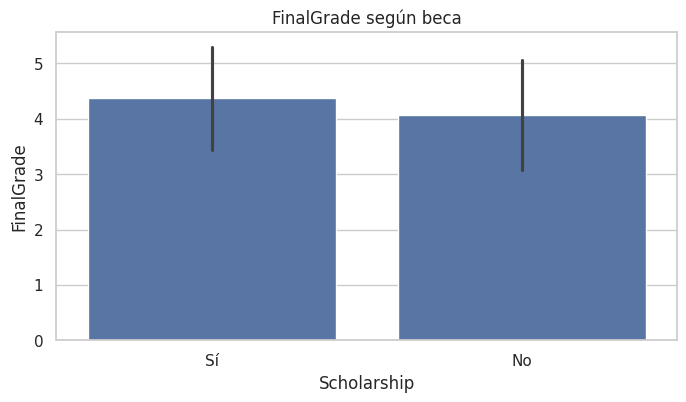

In [49]:
g1 = df_eda.dropna(subset=["Scholarship"]).groupby("Scholarship")[TARGET].agg(["mean","count"])
print(g1.round(3))
dif = g1["mean"]["Sí"] - g1["mean"]["No"]
print(f"\nDiferencia (Sí - No) = {dif:.3f} -> mayor promedio: {'Con beca' if dif>0 else 'Sin beca'}")
sns.barplot(x="Scholarship", y=TARGET, data=df_eda, errorbar="sd"); plt.title("FinalGrade según beca"); plt.show()


**Respuesta:** Los estudiantes con beca presentan un promedio de FinalGrade de 4.37, mientras que los estudiantes sin beca alcanzan un promedio de 4.08. La diferencia observada es de aproximadamente 0.30 puntos a favor de los estudiantes con beca, lo que indica una posible relación entre la tenencia de beca y el rendimiento académico.

Sin embargo, esta diferencia no permite afirmar una relación causal, ya que pueden existir otros factores asociados al desempeño académico.

**Pregunta 2 — ¿Qué programa presenta el mayor promedio de FinalGrade y cuál la diferencia con el menor?**

Program
Contador Auditor          4.051
Ingeniería Civil          4.111
Ingeniería Industrial     4.201
Administración            4.227
Ingeniería Informática    4.232
Name: FinalGrade, dtype: float64

Mayor: Ingeniería Informática (4.232) | Menor: Contador Auditor (4.051) | Dif = 0.181


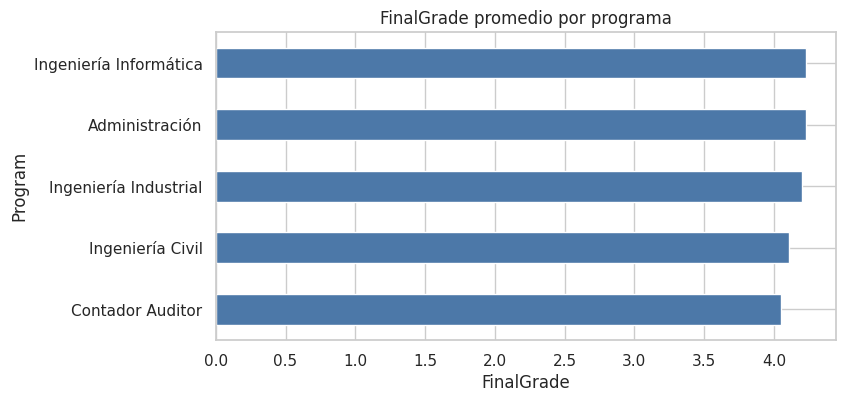

In [50]:
g2 = df_eda.dropna(subset=["Program"]).groupby("Program")[TARGET].mean().sort_values()
print(g2.round(3))
print(f"\nMayor: {g2.idxmax()} ({g2.max():.3f}) | Menor: {g2.idxmin()} ({g2.min():.3f}) | Dif = {g2.max()-g2.min():.3f}")
g2.plot(kind="barh", color="#4C78A8"); plt.title("FinalGrade promedio por programa"); plt.xlabel("FinalGrade"); plt.show()


**Respuesta:** El programa con mayor promedio de FinalGrade corresponde a Ingeniería Informática, con un valor aproximado de 4.23, mientras que el menor promedio corresponde a Contador Auditor, con aproximadamente 4.05.

La diferencia entre ambos programas es de solo 0.18 puntos, por lo que las variaciones de rendimiento entre programas son pequeñas y no evidencian grandes diferencias académicas asociadas exclusivamente al programa de estudio.

**Pregunta 3 — ¿Existe relación entre StudyHours y FinalGrade?**

Pearson = 0.584  |  Spearman = 0.716  (n=4906)


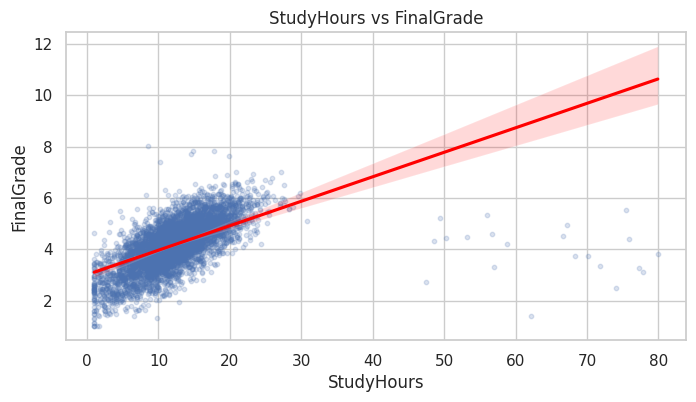

In [51]:
sub = df_eda[["StudyHours",TARGET]].dropna()
r,_=stats.pearsonr(sub["StudyHours"], sub[TARGET])
rho,_=stats.spearmanr(sub["StudyHours"], sub[TARGET])
print(f"Pearson = {r:.3f}  |  Spearman = {rho:.3f}  (n={len(sub)})")
sns.regplot(x="StudyHours", y=TARGET, data=sub, scatter_kws={"alpha":.2,"s":10}, line_kws={"color":"red"})
plt.title("StudyHours vs FinalGrade"); plt.show()


**Respuesta:**  
 Se observa una relación positiva entre StudyHours y FinalGrade. El coeficiente de Pearson (r = 0.584) indica una asociación lineal moderada, mientras que Spearman (ρ = 0.716) muestra una relación monotónica más fuerte.

Esto sugiere que, en general, los estudiantes que dedican más horas al estudio tienden a obtener mejores calificaciones finales. Sin embargo, la dispersión de los datos indica que las horas de estudio no son el único factor que determina el rendimiento académico.

**Pregunta 4 — ¿Existe relación entre Attendance y FinalGrade?**

Pearson = 0.638  |  Spearman = 0.631  (n=4852)


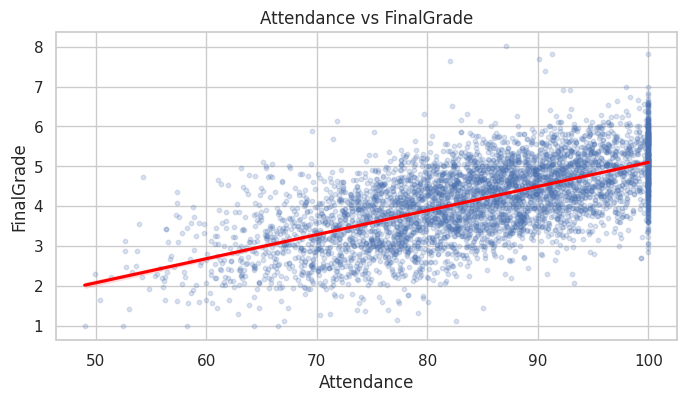

In [52]:
sub = df_eda[["Attendance",TARGET]].dropna()
r,_=stats.pearsonr(sub["Attendance"], sub[TARGET])
rho,_=stats.spearmanr(sub["Attendance"], sub[TARGET])
print(f"Pearson = {r:.3f}  |  Spearman = {rho:.3f}  (n={len(sub)})")
sns.regplot(x="Attendance", y=TARGET, data=sub, scatter_kws={"alpha":.2,"s":10}, line_kws={"color":"red"})
plt.title("Attendance vs FinalGrade"); plt.show()


**Respuesta:**  
 Existe una relación positiva entre Attendance y FinalGrade. El coeficiente de Pearson (r = 0.638) y Spearman (ρ = 0.631) muestran una asociación moderada-fuerte entre ambas variables.

Esto indica que los estudiantes con mayores niveles de asistencia tienden a presentar mejores calificaciones finales. La tendencia observada en el gráfico de dispersión y la recta de regresión respaldan esta relación.

### Interpretación del EDA — 3 conclusiones generales

1. **El rendimiento académico se relaciona principalmente con variables asociadas al desempeño y compromiso académico.** Las variables con mayor correlación positiva con FinalGrade fueron AssignmentsCompleted (≈0.69), PreviousGPA (≈0.66), Attendance (≈0.64) y StudyHours (≈0.58). Esto sugiere que el cumplimiento de actividades, antecedentes académicos, asistencia y dedicación al estudio tienen mayor relación con el rendimiento que variables demográficas como la edad.
2. **Existen diferencias de rendimiento según algunas características del estudiante, aunque son moderadas.** Los estudiantes con beca presentan un promedio superior de FinalGrade respecto a quienes no tienen beca, con una diferencia aproximada de 0.30 puntos. En cambio, las diferencias entre programas académicos son reducidas, con una diferencia máxima cercana a 0.18 puntos, indicando que el programa por sí solo no explica grandes variaciones en el rendimiento.
3. **La calidad del dato fue un aspecto fundamental antes del análisis exploratorio.** Se detectaron registros duplicados, inconsistencias en variables categóricas y valores fuera de dominio, como asistencias negativas o notas fuera de escala. El tratamiento previo permitió evitar que estos errores afectaran los promedios, correlaciones y conclusiones obtenidas del dataset.

---
# 3. Tratamiento de los datos

Resumen de decisiones, **cada una fundamentada en el diagnóstico**:

| Problema | Hallazgo (sección) | Decisión | Justificación |
|---|---|---|---|
| Duplicados | 100 filas idénticas (1.3) | Eliminar duplicados exactos | Registros repetidos que sesgan estadísticos |
| Inconsistencias de texto | `Scholarship`/`Program` mal escritos (1.4) | Normalizar a categorías canónicas | Unifica categorías que representan lo mismo |
| Valores inválidos | Fuera de dominio (1.4) | Convertir a `NaN` → imputar | Son imposibles; se tratan como faltantes |
| Valores faltantes | 1,4–4,4 % por variable (1.2) | Mantener como valores faltantes | Serán tratados posteriormente mediante imputación reproducible en Pipeline |
| Outliers extremos | Extremos plausibles (1.5) | Acotar por IQR (winsorización) | Conserva el registro y limita el efecto del extremo |
| Target `FinalGrade` | 4 notas inválidas (1.4) | Separar + eliminar filas con target inválido | El target no se imputa: una observación sin nota válida no es utilizable |


In [53]:
# Tratamiento inicial de calidad de datos:
# eliminación de duplicados, normalización categórica y corrección de valores inválidos
def limpieza_base(data):
    d = data.drop_duplicates().copy()                       # (a) elimina duplicados exactos
    d["Scholarship"] = d["Scholarship"].map(normaliza_scholarship)  # (b) normaliza categóricas
    d["Program"]     = d["Program"].map(normaliza_program)
    for c,(lo,hi) in DOMINIOS.items():                      # (c) valores inválidos -> NaN
        d.loc[(d[c]<lo)|(d[c]>hi), c] = np.nan
    n_target_inv = d[TARGET].isna().sum()                   # (d) target inválido -> se elimina la fila
    d = d.dropna(subset=[TARGET]).reset_index(drop=True)
    print(f"Filas con FinalGrade inválida eliminadas: {n_target_inv} "
          f"(el target no se imputa: se descarta la observación)")
    return d

df_base = limpieza_base(df_original)
print("Antes :", df_original.shape, "-> Después de limpieza base:", df_base.shape)
print("Duplicados restantes:", df_base.duplicated().sum())
print("Valores faltantes generados después de corregir valores inválidos:")
display(df_base.isna().sum())

print("Categorías finales:")
display(df_base["Scholarship"].value_counts())
display(df_base["Program"].value_counts())


Filas con FinalGrade inválida eliminadas: 4 (el target no se imputa: se descarta la observación)
Antes : (5100, 11) -> Después de limpieza base: (4996, 11)
Duplicados restantes: 0
Valores faltantes generados después de corregir valores inválidos:


,0
StudentID,0
Age,114
StudyHours,189
Attendance,240
PreviousGPA,160
AssignmentsCompleted,210
SleepHours,128
InternetHours,200
Scholarship,80
Program,70


Categorías finales:


,count
Scholarship,
No,3314
Sí,1602


,count
Program,
Ingeniería Informática,1420
Ingeniería Industrial,1091
Ingeniería Civil,986
Administración,777
Contador Auditor,652


Luego de aplicar la limpieza inicial, el dataset pasó de 5100 a 4996 registros. La reducción corresponde principalmente a la eliminación de duplicados exactos y registros con valores inválidos en la variable objetivo FinalGrade. Además, se verificó que no permanecieran duplicados completos.

---
# 4. Implementación mediante Pipeline / ColumnTransformer

Se implementa el tratamiento **reproducible** con scikit-learn. La variable `FinalGrade` se mantiene **separada** como target (`y`) y `StudentID` se descarta por ser identificador.

- **Numéricas:** imputación (mediana) → acotamiento de outliers por IQR (transformador propio) → estandarización.
- **Categóricas:** imputación (moda) → codificación One-Hot.

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin

class IQROutlierCapper(BaseEstimator, TransformerMixin):
    """Acota (winsoriza) valores extremos usando la regla IQR aprendida en fit."""
    def __init__(self, factor=1.5):
        self.factor = factor
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        q1 = np.nanpercentile(X, 25, axis=0)
        q3 = np.nanpercentile(X, 75, axis=0)
        iqr = q3 - q1
        self.lower_ = q1 - self.factor*iqr
        self.upper_ = q3 + self.factor*iqr
        return self
    def transform(self, X):
        X = np.asarray(X, dtype=float).copy()
        return np.clip(X, self.lower_, self.upper_)

X = df_base.drop(columns=[ID_COL, TARGET])
y = df_base[TARGET]

pipe_num = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("outliers", IQROutlierCapper(factor=1.5)),
    ("scaler", StandardScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocesador = ColumnTransformer([
    ("num", pipe_num, NUMERICAS),
    ("cat", pipe_cat, CATEGORICAS),
])

X_transformado = preprocesador.fit_transform(X)
print("Matriz de features transformada (lista para modelar):", X_transformado.shape)


Matriz de features transformada (lista para modelar): (4996, 14)


### 4.1 Dataset limpio legible

El bloque anterior deja los datos listos para **modelar** (escalados y codificados). Para el **entregable legible** aplicamos las mismas reglas de imputación y acotamiento de outliers **sin** escalar ni codificar, de modo que los valores sigan siendo interpretables.

In [55]:
# Mismas reglas, versión legible (imputa + acota, mantiene categorías y escala original)
imp_num = SimpleImputer(strategy="median")
cap     = IQROutlierCapper(factor=1.5)
imp_cat = SimpleImputer(strategy="most_frequent")

df_limpio = df_base.copy()
num_imp = imp_num.fit_transform(df_limpio[NUMERICAS])
num_cap = cap.fit_transform(num_imp)
df_limpio[NUMERICAS] = np.round(num_cap, 2)
df_limpio[CATEGORICAS] = imp_cat.fit_transform(df_limpio[CATEGORICAS])

print("Dataset limpio:", df_limpio.shape)
print("Faltantes restantes:", int(df_limpio.isna().sum().sum()))
df_limpio.head()


Dataset limpio: (4996, 11)
Faltantes restantes: 0


,StudentID,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship,Program,FinalGrade
0,STU-10522,22.0,10.70,83.73,6.09,69.15,6.27,4.39,Sí,Ingeniería Industrial,3.96
1,STU-10947,23.0,9.86,99.60,6.76,76.95,6.52,8.03,No,Ingeniería Informática,5.09
2,STU-11352,26.0,13.43,92.65,6.07,95.99,6.70,6.37,No,Contador Auditor,4.37
3,STU-12298,27.0,20.77,81.73,5.09,90.96,6.16,5.81,No,Contador Auditor,4.02
4,STU-13527,20.0,6.27,70.17,4.84,64.20,6.30,4.10,No,Ingeniería Civil,3.24


El Pipeline aplicado genera una matriz preparada para modelamiento predictivo con 4996 observaciones y 14 variables transformadas. El número de variables aumenta debido a la codificación One-Hot de las variables categóricas.

El proceso mantiene separado el objetivo FinalGrade y elimina StudentID, evitando incorporar información identificatoria al modelo. Las variables numéricas fueron imputadas, acotadas mediante la regla IQR y posteriormente estandarizadas, mientras que las variables categóricas fueron imputadas mediante la moda y transformadas mediante One-Hot Encoding.

---
# 5. Dataset final, validación y evidencia
###**Validación final de calidad**

Luego de aplicar las estrategias de tratamiento definidas, se realiza una nueva evaluación de calidad sobre el dataset resultante. Se verifican valores faltantes, registros duplicados, valores fuera de dominio y consistencia de las variables categóricas.

In [56]:
# Re-validación de calidad sobre el dataset tratado
print("Registros            :", df_limpio.shape[0])
print("Variables            :", df_limpio.shape[1])
print("Faltantes totales    :", int(df_limpio.isna().sum().sum()))
print("Duplicados           :", int(df_limpio.duplicated().sum()))
inval = sum(int(((df_limpio[c]<lo)|(df_limpio[c]>hi)).sum()) for c,(lo,hi) in DOMINIOS.items())
print("Valores fuera de dominio:", inval)
print("Categorías Scholarship:", df_limpio['Scholarship'].unique().tolist())
print("Categorías Program    :", sorted(df_limpio['Program'].dropna().unique().tolist()))


Registros            : 4996
Variables            : 11
Faltantes totales    : 0
Duplicados           : 0
Valores fuera de dominio: 0
Categorías Scholarship: ['Sí', 'No']
Categorías Program    : ['Administración', 'Contador Auditor', 'Ingeniería Civil', 'Ingeniería Industrial', 'Ingeniería Informática']


In [57]:
# Tabla comparativa: dataset original vs tratado
def n_invalidos(data):
    return sum(int(((data[c]<lo)|(data[c]>hi)).sum()) for c,(lo,hi) in DOMINIOS.items())
def n_outliers(data):
    tot=0
    for c in NUMERICAS+[TARGET]:
        s=data[c].dropna(); q1,q3=s.quantile([.25,.75]); iqr=q3-q1
        tot+=int(((s<q1-1.5*iqr)|(s>q3+1.5*iqr)).sum())
    return tot

comparacion = pd.DataFrame({
    "Indicador":["Cantidad de registros","Cantidad de variables","Valores faltantes",
                 "Registros duplicados","Inconsistencias","Outliers tratados"],
    "Dataset original":[df_original.shape[0], df_original.shape[1], int(df_original.isna().sum().sum()),
                        int(df_original.duplicated().sum()), n_invalidos(df_original), n_outliers(df_original)],
    "Dataset tratado":[df_limpio.shape[0], df_limpio.shape[1], int(df_limpio.isna().sum().sum()),
                       int(df_limpio.duplicated().sum()), n_invalidos(df_limpio), 0],
})
comparacion


,Indicador,Dataset original,Dataset tratado
0,Cantidad de registros,5100,4996
1,Cantidad de variables,11,11
2,Valores faltantes,1335,0
3,Registros duplicados,100,0
4,Inconsistencias,87,0
5,Outliers tratados,393,0


In [58]:
# Exportar el dataset tratado
df_limpio.to_csv("rendimiento_academico_limpio.csv", index=False)
print("Archivo exportado: rendimiento_academico_limpio.csv", df_limpio.shape)


Archivo exportado: rendimiento_academico_limpio.csv (4996, 11)


**Estado final del dataset:** El proceso de tratamiento permitió corregir los problemas de calidad identificados inicialmente. Se eliminaron registros duplicados, se normalizaron variables categóricas, se corrigieron valores inválidos y se trataron valores faltantes mediante estrategias reproducibles. El dataset final quedó preparado para etapas posteriores de modelamiento.